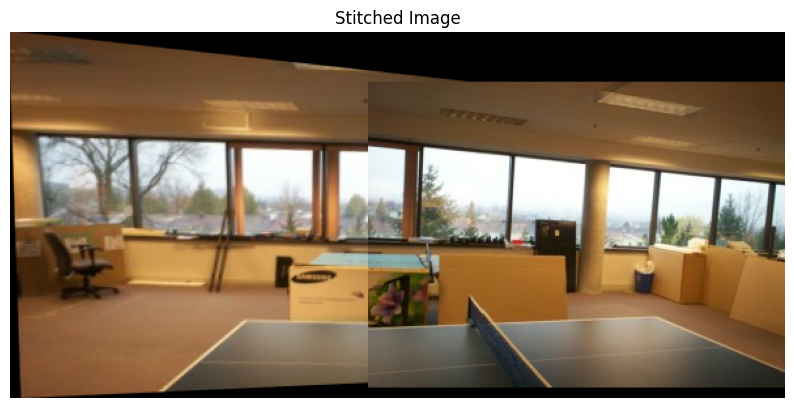

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def extract_features_harris(image):
    """
    Extract keypoints and descriptors using Harris corner detection and ORB.
    """
    gray = np.float32(image)
    harris_corners = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
    harris_corners = cv2.dilate(harris_corners, None)
    threshold = 0.01 * harris_corners.max()
    keypoints = np.argwhere(harris_corners > threshold)

    if len(keypoints) == 0:
        return [], None

    keypoints = [cv2.KeyPoint(float(x[1]), float(x[0]), 1) for x in keypoints]
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.compute(image, keypoints)

    if descriptors is None:
        return [], None

    return keypoints, descriptors


def match_features(descriptors1, descriptors2):
    if descriptors1 is None or descriptors2 is None or len(descriptors1) == 0 or len(descriptors2) == 0:
        print("Descriptors are invalid or empty. Skipping matching.")
        return []

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(descriptors1, descriptors2)
    matches = sorted(matches, key=lambda x: x.distance)
    return matches


def find_homography(kp1, kp2, matches):
    if len(matches) < 4:
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, status = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    return H


def warp_and_stitch(image1, image2, H):
    if H is None:
        print("Homography matrix is invalid. Cannot stitch images.")
        return None

    height1, width1 = image1.shape[:2]
    height2, width2 = image2.shape[:2]

    # Calculate the size of the output canvas
    corners = np.float32([[0, 0], [0, height1], [width1, height1], [width1, 0]]).reshape(-1, 1, 2)
    warped_corners = cv2.perspectiveTransform(corners, H)
    image2_corners = np.float32([[0, 0], [0, height2], [width2, height2], [width2, 0]]).reshape(-1, 1, 2)

    # Combine all corners
    all_corners = np.concatenate((warped_corners, image2_corners), axis=0)

    # Calculate the output canvas size
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel())
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel())

    # Translation matrix to shift the output canvas
    translation = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]])  # Shift to fit everything

    # Warp the first image
    result = cv2.warpPerspective(image1, translation @ H, (x_max - x_min, y_max - y_min))

    # Blend the second image into the result
    x_offset, y_offset = -x_min, -y_min
    result[y_offset:y_offset + height2, x_offset:x_offset + width2] = image2

    return result


def main():
    image1 = cv2.imread('/content/sample_data/EP1.png', cv2.IMREAD_COLOR)
    image2 = cv2.imread('/content/sample_data/EP2.png', cv2.IMREAD_COLOR)

    if image1 is None or image2 is None:
        print("Error: One or both images could not be loaded.")
        return

    gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    kp1, desc1 = extract_features_harris(gray1)
    kp2, desc2 = extract_features_harris(gray2)

    if desc1 is None or desc2 is None or len(desc1) == 0 or len(desc2) == 0:
        print("Not enough features detected. Exiting.")
        return

    matches = match_features(desc1, desc2)

    if len(matches) < 4:
        print("Not enough matches found for homography!")
        return

    H = find_homography(kp1, kp2, matches)

    result = warp_and_stitch(image1, image2, H)

    if result is None:
        print("Image stitching failed.")
        return

    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Stitched Image')
    plt.show()

    cv2.imwrite('stitched_result.jpg', result)


if __name__ == "__main__":
    main()


Homographies are not valid numpy arrays.


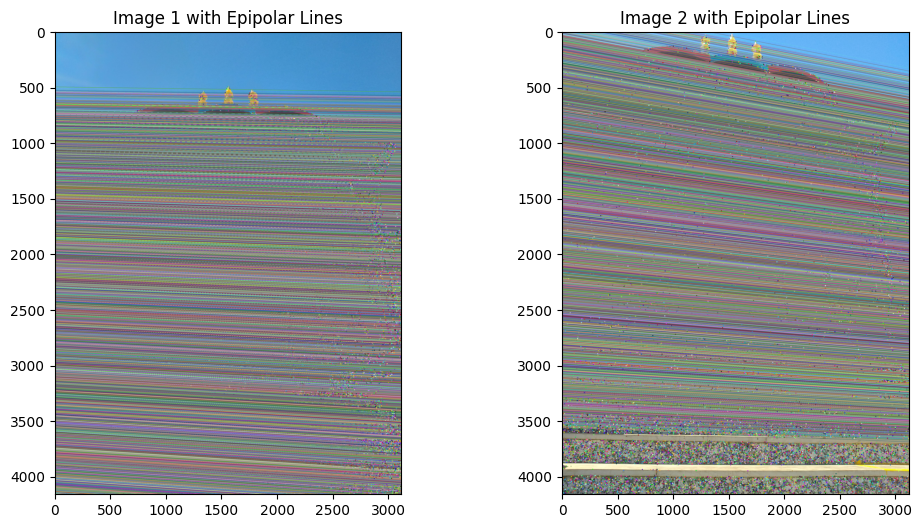

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_images(img1_path, img2_path):
    """Load two images from the given paths."""
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    return img1, img2

def detect_and_match_keypoints(img1, img2):
    """Detect keypoints and match them using SIFT and BFMatcher."""
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)

    pts1 = np.array([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.array([kp2[m.trainIdx].pt for m in matches])

    return pts1, pts2

def rectify_images(img1, img2, pts1, pts2):
    """Perform stereo rectification on the images."""
    # Step 1: Compute the fundamental matrix
    F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)

    if F is None:
        print("Fundamental matrix computation failed.")
        return img1, img2, None

    # Step 2: Perform stereo rectification
    result = cv2.stereoRectifyUncalibrated(pts1, pts2, F, img1.shape[:2])

    if result is False:  # If stereoRectifyUncalibrated fails
        print("Stereo rectification failed. Please check the input points.")
        return img1, img2, F

    # Step 3: Unpack the result into H1, H2, and mask
    H1, H2, mask = result

    if H1 is None or H2 is None:
        print("Stereo rectification did not return valid homographies.")
        return img1, img2, F

    # Step 4: Ensure homographies are in the correct type
    if isinstance(H1, np.ndarray) and isinstance(H2, np.ndarray):
        H1 = H1.astype(np.float32)
        H2 = H2.astype(np.float32)
    else:
        print("Homographies are not valid numpy arrays.")
        return img1, img2, F

    # Step 5: Apply warpPerspective to rectify the images
    img1_rectified = cv2.warpPerspective(img1, H1, img1.shape[:2])
    img2_rectified = cv2.warpPerspective(img2, H2, img2.shape[:2])

    return img1_rectified, img2_rectified, F

def draw_epipolar_lines(img1, img2, pts1, pts2, F):
    """Draw epipolar lines on the rectified images."""
    def draw_lines(img, lines, points):
        for line, pt in zip(lines, points):
            color = tuple(np.random.randint(0, 255, 3).tolist())
            x0, y0 = map(int, [0, -line[2] / line[1]])
            x1, y1 = map(int, [img.shape[1], -(line[2] + line[0] * img.shape[1]) / line[1]])
            img = cv2.line(img, (x0, y0), (x1, y1), color, 1)
            img = cv2.circle(img, tuple(map(int, pt)), 5, color, -1)
        return img

    lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2, F).reshape(-1, 3)
    lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F).reshape(-1, 3)

    img1_with_lines = draw_lines(img1.copy(), lines1, pts1)
    img2_with_lines = draw_lines(img2.copy(), lines2, pts2)

    return img1_with_lines, img2_with_lines

def main():
    img1_path = '/content/sample_data/EP1.jpg'
    img2_path = '/content/sample_data/EP2.jpg'

    # Load images
    img1, img2 = load_images(img1_path, img2_path)

    # Detect keypoints and match them
    pts1, pts2 = detect_and_match_keypoints(img1, img2)

    # Rectify images
    img1_rectified, img2_rectified, F = rectify_images(img1, img2, pts1, pts2)

    if F is None:
        print("Rectification failed. Cannot proceed with drawing epipolar lines.")
        return

    # Draw epipolar lines
    img1_lines, img2_lines = draw_epipolar_lines(img1_rectified, img2_rectified, pts1, pts2, F)

    # Display results
    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(cv2.cvtColor(img1_lines, cv2.COLOR_BGR2RGB)), plt.title("Image 1 with Epipolar Lines")
    plt.subplot(122), plt.imshow(cv2.cvtColor(img2_lines, cv2.COLOR_BGR2RGB)), plt.title("Image 2 with Epipolar Lines")
    plt.show()

if __name__ == "__main__":
    main()


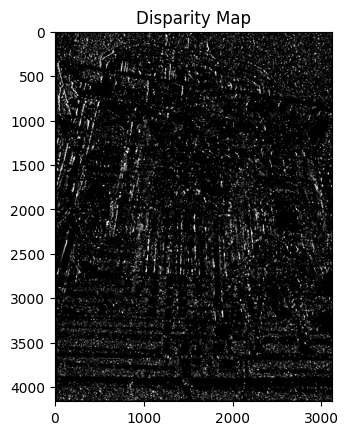

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img1 = cv2.imread("/content/sample_data/EP1.jpg")
img2 = cv2.imread("/content/sample_data/EP2.jpg")


# Create a StereoBM object for disparity calculation
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

# Convert the images to grayscale for disparity calculation
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Compute disparity
disparity = stereo.compute(gray1, gray2)

# Show the disparity map
plt.imshow(disparity, cmap='gray')
plt.title('Disparity Map')
plt.show()


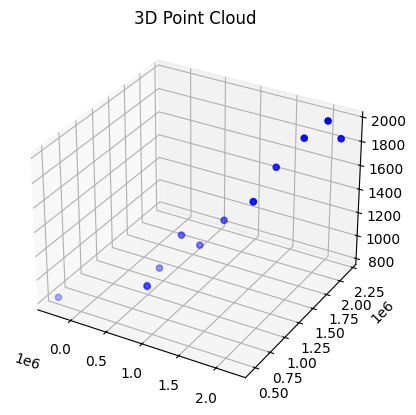

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_images(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    return img1, img2

def detect_and_match_keypoints(img1, img2, max_features=50):
    """Detect and match keypoints using SIFT and BFMatcher."""
    # Initialize SIFT
    sift = cv2.SIFT_create(max_features)

    # Detect keypoints and descriptors
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    # Match descriptors using BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)

    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)

    # Extract the top matches (limited by max_features)
    matches = matches[:max_features]
    pts1 = np.array([kp1[m.queryIdx].pt for m in matches], dtype=np.float32)
    pts2 = np.array([kp2[m.trainIdx].pt for m in matches], dtype=np.float32)

    return pts1, pts2

def compute_fundamental_matrix(pts1, pts2):
    """Compute the fundamental matrix."""
    F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)
    return F, mask

def compute_projection_matrices(F, K):
    """Compute projection matrices P1 and P2 from the fundamental matrix."""
    # Define the first camera matrix (P1 = [K | 0])
    P1 = np.dot(K, np.hstack((np.eye(3), np.zeros((3, 1)))))

    # Compute the second camera matrix (P2)
    _, _, Vt = np.linalg.svd(F)
    e = Vt[-1] / Vt[-1][2]  # Epipole in the second image
    T = np.array([[0, -e[2], e[1]],
                  [e[2], 0, -e[0]],
                  [-e[1], e[0], 0]])
    E = np.dot(T, F)
    P2 = np.dot(K, np.hstack((E, e.reshape(-1, 1))))

    return P1, P2

def triangulate_points(pts1, pts2, P1, P2):
    """Triangulate 3D points."""
    # Convert points to homogeneous coordinates
    pts1_hom = cv2.convertPointsToHomogeneous(pts1).reshape(-1, 3).T
    pts2_hom = cv2.convertPointsToHomogeneous(pts2).reshape(-1, 3).T

    # Triangulate points
    points_3D_hom = cv2.triangulatePoints(P1, P2, pts1_hom[:2], pts2_hom[:2])

    # Convert to non-homogeneous coordinates
    points_3D = (points_3D_hom / points_3D_hom[3]).T[:, :3]

    return points_3D

def visualize_3D_points(points_3D):
    """Visualize the 3D points."""
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points_3D[:, 0], points_3D[:, 1], points_3D[:, 2], c='b', marker='o')
    ax.set_title("3D Point Cloud")
    plt.show()

def main():
    img1_path = "/content/sample_data/EP1.jpg"
    img2_path = "/content/sample_data/EP2.jpg"

    # Load images
    img1, img2 = load_images(img1_path, img2_path)

    # Detect and match keypoints
    pts1, pts2 = detect_and_match_keypoints(img1, img2)

    # Compute the fundamental matrix
    F, mask = compute_fundamental_matrix(pts1, pts2)

    # Camera intrinsic matrix (assuming a basic example, adjust for your camera)
    K = np.array([[1000, 0, img1.shape[1] / 2],
                  [0, 1000, img1.shape[0] / 2],
                  [0, 0, 1]])

    # Compute projection matrices
    P1, P2 = compute_projection_matrices(F, K)

    # Triangulate 3D points
    points_3D = triangulate_points(pts1, pts2, P1, P2)

    # Visualize the 3D points
    visualize_3D_points(points_3D)

if __name__ == "__main__":
    main()
